In [2]:
library(tidyverse)
list.files(path = "../input")

[1] "accepted-2007-to-2018q4-csv"

[1] "Loading dataset..."


[1] 2260701     151

[1] "Checking loan_status values:"

                                                    
                                                 33 
                                        Charged Off 
                                             268559 
                                            Current 
                                             878317 
                                            Default 
                                                 40 
Does not meet the credit policy. Status:Charged Off 
                                                761 
 Does not meet the credit policy. Status:Fully Paid 
                                               1988 
                                         Fully Paid 
                                            1076751 
                                    In Grace Period 
                                               8436 
                                  Late (16-30 days) 
                                               4349 
          

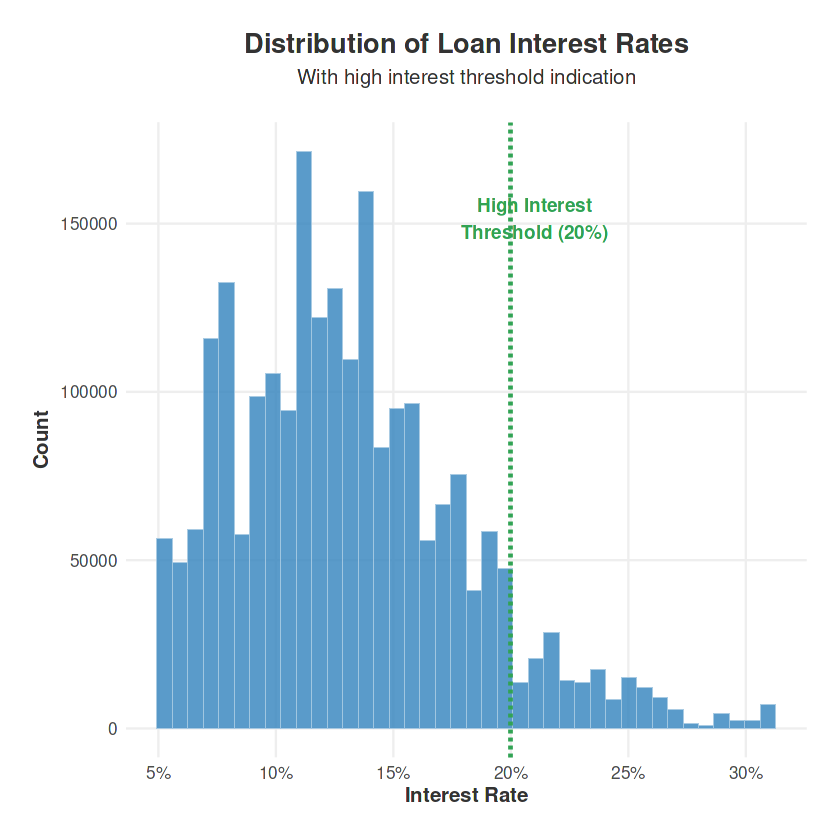

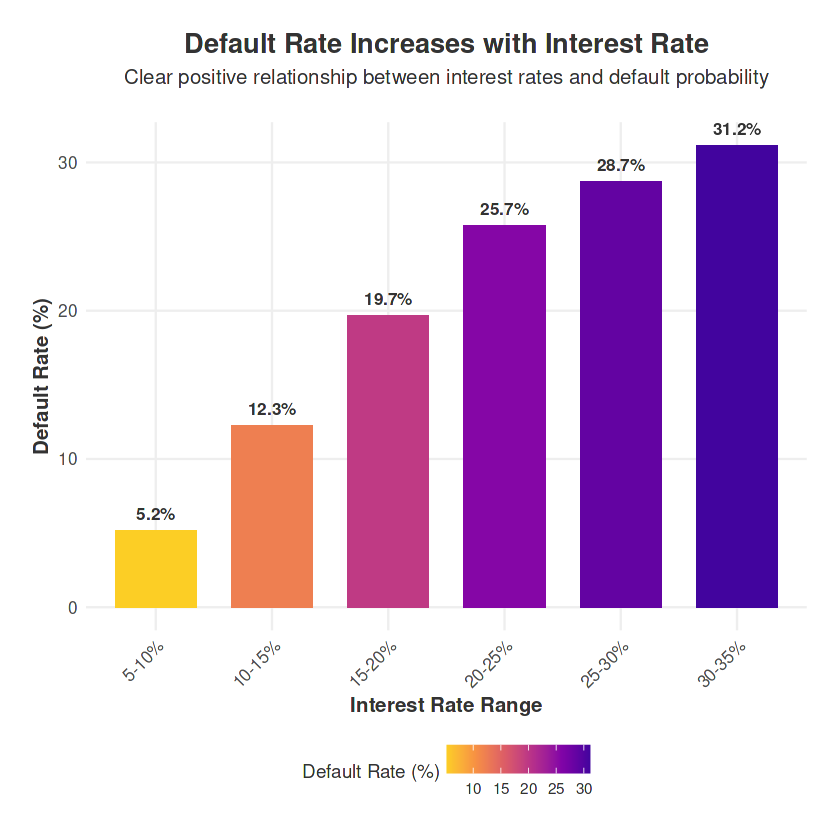

[1] "Creating analysis sample..."
[1] "Missing values in key variables:"
          loan_amnt               grade          annual_inc                term 
                  2                   0                   2                   0 
         emp_length      home_ownership verification_status            int_rate 
                  0                   0                   0                   2 
            default 
                  0 
[1] "Complete cases for analysis: 49998"
[1] "Performing propensity score matching..."

Call:
matchit(formula = match_formula, data = clean_data, method = "nearest", 
    replace = FALSE, ratio = 1)

Summary of Balance for All Data:
                                   Means Treated Means Control Std. Mean Diff.
distance                                  0.6506        0.0304          2.0522
loan_amnt                             17721.5912    14811.6633          0.3080
gradeA                                    0.0000        0.2086         -0.5352
gradeB      

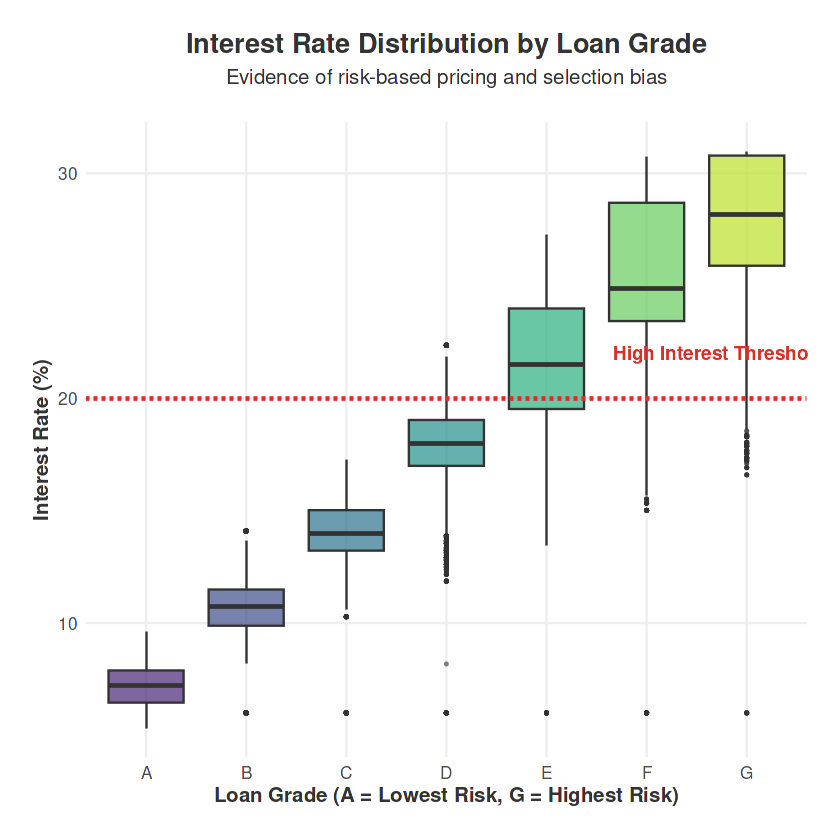

[1] "Estimating treatment effect..."

Call:
glm(formula = default ~ high_interest + loan_amnt + annual_inc + 
    grade, family = binomial(link = "logit"), data = matched_data)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -1.479e+00  6.906e-02 -21.414  < 2e-16 ***
high_interest -3.367e-01  6.512e-02  -5.170 2.34e-07 ***
loan_amnt      2.173e-05  3.040e-06   7.146 8.97e-13 ***
annual_inc    -2.816e-06  6.386e-07  -4.409 1.04e-05 ***
gradeE         6.034e-01  6.456e-02   9.346  < 2e-16 ***
gradeF         1.034e+00  9.480e-02  10.909  < 2e-16 ***
gradeG         1.351e+00  1.408e-01   9.598  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 9196.5  on 7993  degrees of freedom
Residual deviance: 8946.7  on 7987  degrees of freedom
AIC: 8960.7

Number of Fisher Scoring iterations: 4

[1] "Odds ratios:"
# A tibble: 7 × 7
  term          estimate  

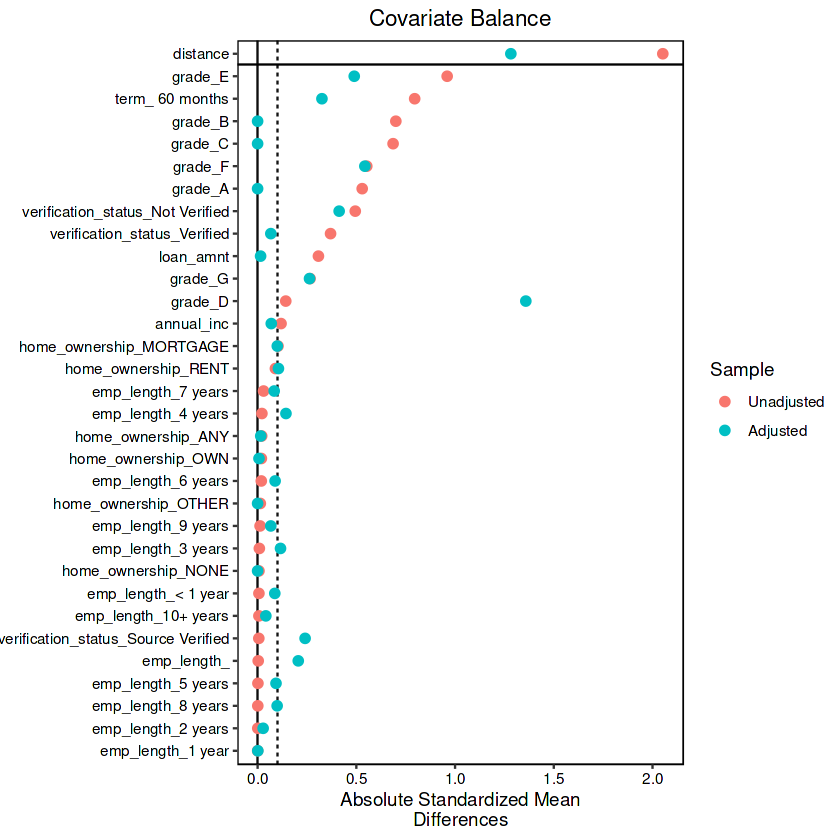

In [6]:
# =======================================================
# The Causal Effect of High vs. Low Interest Rates on Loan Default Probability
# ECON 318: Applied Econometrics - Final Project
# =======================================================

# packages to load
library(tidyverse)
library(MatchIt)
library(cobalt)
library(broom)
library(viridis)
library(scales)

# se t of seed for reproducibility
set.seed(123)

# theme for plots
elegant_theme <- theme_minimal() +
  theme(
    text = element_text(color = "#333333"),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5, margin = margin(b = 20)),
    axis.title = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 10),
    legend.position = "bottom",
    panel.grid.major = element_line(color = "#eeeeee"),
    panel.grid.minor = element_blank(),
    plot.margin = margin(20, 20, 20, 20)
  )

# -----= DATA LOADING AND PREPROCESSING ----=
print("Loading dataset...")
loans <- read.csv("/kaggle/input/accepted-2007-to-2018q4-csv/accepted_2007_to_2018Q4.csv")
dim(loans)

# interest rate to numeric conversion
if(is.character(loans$int_rate)) {
  loans$int_rate <- as.numeric(gsub("%", "", loans$int_rate))
}

# default statuses
default_statuses <- c("Charged Off", "Default", "Late (31-120 days)", 
                      "Late (16-30 days)", "Does not meet the credit policy. Status:Charged Off")

# default indicator
loans$default <- ifelse(loans$loan_status %in% default_statuses, 1, 0)

# Creating high interest rate indicator - 20% threshold
loans$high_interest <- ifelse(loans$int_rate > 20, 1, 0)

# ======== EXPLORATORY DATA ANALYSIS ========
# we are checking the loan status distribution
print("Checking loan_status values:")
print(table(loans$loan_status))

# Interest rate summary
print("Interest rate summary:")
print(summary(loans$int_rate))

# High interest rate distribution
print("High interest rate distribution:")
print(table(loans$high_interest))
print(paste0("Proportion with high interest rates: ", 
             round(mean(loans$high_interest, na.rm = TRUE) * 100, 2), "%"))

# Default distribution
print("Default distribution:")
print(table(loans$default))
print(paste0("Default rate: ", round(mean(loans$default, na.rm = TRUE) * 100, 2), "%"))

# Figure 1: Distribution of interest rates
loans_clean <- loans %>% filter(!is.na(int_rate))

p1 <- ggplot(loans_clean, aes(x = int_rate)) +
  geom_histogram(bins = 40, fill = "#3182bd", alpha = 0.8, color = "white", size = 0.1) +
  geom_vline(xintercept = 20, linetype = "dashed", color = "#31a354", linewidth = 1) +
  annotate("text", x = 21, y = max(table(cut(loans_clean$int_rate, breaks = 40))), 
          label = "High Interest\nThreshold (20%)", color = "#31a354", fontface = "bold") +
  scale_x_continuous(breaks = seq(0, 35, by = 5), labels = function(x) paste0(x, "%")) +
  labs(title = "Distribution of Loan Interest Rates",
       subtitle = "With high interest threshold indication",
       x = "Interest Rate",
       y = "Count") +
  elegant_theme

print(p1)
ggsave("figure1_interest_rate_distribution.png", p1, width = 10, height = 6, dpi = 300)

# interest rate bins
loans$interest_bin <- cut(loans$int_rate, 
                         breaks = c(0, 5, 10, 15, 20, 25, 30, 35, 40, 100),
                         labels = c("0-5%", "5-10%", "10-15%", "15-20%", 
                                   "20-25%", "25-30%", "30-35%", "35-40%", "40%+"),
                         right = FALSE)

# Figure 2: Default rate by interest rate range
default_by_interest <- aggregate(default ~ interest_bin, data = loans, 
                               FUN = function(x) c(mean = mean(x, na.rm = TRUE), count = length(x)))
default_by_interest <- data.frame(
  interest_bin = default_by_interest$interest_bin,
  default_rate = unlist(default_by_interest$default[,"mean"]),
  count = unlist(default_by_interest$default[,"count"])
)

default_by_interest$default_pct <- default_by_interest$default_rate * 100

p2 <- ggplot(default_by_interest, aes(x = interest_bin, y = default_pct)) +
  geom_bar(stat = "identity", aes(fill = default_pct), width = 0.7) +
  geom_text(aes(label = sprintf("%.1f%%", default_pct)), 
           vjust = -0.8, color = "#333333", fontface = "bold", size = 3.5) +
  scale_fill_viridis_c(option = "plasma", direction = -1, begin = 0.1, end = 0.9,
                     name = "Default Rate (%)") +
  labs(title = "Default Rate Increases with Interest Rate",
       subtitle = "Clear positive relationship between interest rates and default probability",
       x = "Interest Rate Range",
       y = "Default Rate (%)") +
  elegant_theme +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

print(p2)
ggsave("figure2_default_by_interest_rate.png", p2, width = 10, height = 6, dpi = 300)

# Figure 3: Interest Rate vs. Grade
p3 <- ggplot(loans_clean, aes(x = grade, y = int_rate)) +
  geom_boxplot(aes(fill = grade), alpha = 0.7, outlier.shape = 16, outlier.size = 0.8, outlier.alpha = 0.6) +
  scale_fill_viridis_d(option = "viridis", begin = 0.1, end = 0.9) +
  geom_hline(yintercept = 20, linetype = "dashed", color = "#d73027", linewidth = 1) +
  annotate("text", x = "G", y = 22, label = "High Interest Threshold (20%)", 
          color = "#d73027", fontface = "bold") +
  labs(title = "Interest Rate Distribution by Loan Grade",
       subtitle = "Evidence of risk-based pricing and selection bias",
       x = "Loan Grade (A = Lowest Risk, G = Highest Risk)",
       y = "Interest Rate (%)") +
  elegant_theme +
  theme(legend.position = "none")

print(p3)
ggsave("figure3_interest_rate_by_grade.png", p3, width = 10, height = 6, dpi = 300)

# ------- PROPENSITY SCORE MATCHING ========
# we are creating a more manageable sample for PSM analysis
print("Creating analysis sample...")
sample_size <- 50000  
sample_indices <- sample(1:nrow(loans), sample_size)
analysis_data <- loans[sample_indices, ]

# variables for matching
matching_vars <- c("loan_amnt", "grade", "annual_inc", "term", "emp_length", 
                  "home_ownership", "verification_status")
na_count <- colSums(is.na(analysis_data[, c(matching_vars, "int_rate", "default")]))
print("Missing values in key variables:")
print(na_count)

# Create a clean subset with complete cases
clean_data <- na.omit(analysis_data[, c(matching_vars, "int_rate", "high_interest", "default")])
print(paste("Complete cases for analysis:", nrow(clean_data)))

# Create formula for matching
match_formula <- as.formula(paste("high_interest ~", paste(matching_vars, collapse = " + ")))

# Perform propensity score matching
print("Performing propensity score matching...")
match_obj <- matchit(match_formula, 
                   data = clean_data,
                   method = "nearest", 
                   ratio = 1,
                   replace = FALSE)

# Print matching summary
print(summary(match_obj))

# Get matched data
matched_data <- match.data(match_obj)
print(paste("Matched sample size:", nrow(matched_data)))

# Figure 4: Balance plot
print("Creating balance plot...")
bal_plot <- love.plot(match_obj, 
                    var.order = "unadjusted",
                    abs = TRUE,
                    threshold = 0.1,
                    binary = "std")
print(bal_plot)
ggsave("figure4_balance_plot.png", bal_plot, width = 10, height = 8, dpi = 300)

# ======== TREATMENT EFFECT ESTIMATION ========
# Estimating treatment effect
print("Estimating treatment effect...")
outcome_model <- glm(default ~ high_interest + loan_amnt + annual_inc + grade, 
                   family = binomial(link = "logit"), 
                   data = matched_data)

summary_result <- summary(outcome_model)
print(summary_result)

# calculatinh odds ratios
tidy_model <- tidy(outcome_model, conf.int = TRUE, exponentiate = TRUE)
print("Odds ratios:")
print(tidy_model)

                                 
                                 
# Figure 5: Enhanced treatment effect plot 
high_interest_effect <- tidy_model[tidy_model$term == "high_interest", ]

p5 <- ggplot() +
  # gradient background
  annotate("rect", xmin = 0.5, xmax = 1.5, ymin = 0, ymax = 1, 
          fill = "gray95", alpha = 0.5) +
  
  # vertical reference lines
  geom_vline(xintercept = 0.7, linetype = "dotted", color = "gray60", linewidth = 0.5) +
  geom_vline(xintercept = 0.8, linetype = "dotted", color = "gray60", linewidth = 0.5) +
  geom_vline(xintercept = 0.9, linetype = "dotted", color = "gray60", linewidth = 0.5) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "#E41A1C", linewidth = 1.2) +
  geom_vline(xintercept = 1.1, linetype = "dotted", color = "gray60", linewidth = 0.5) +
  geom_vline(xintercept = 1.2, linetype = "dotted", color = "gray60", linewidth = 0.5) +
  
  # confidence interval as a shaded area
  geom_rect(aes(xmin = high_interest_effect$conf.low, 
                xmax = high_interest_effect$conf.high,
                ymin = 0.4, ymax = 0.6),
            fill = "#4292C6", alpha = 0.2) +
  
  # confidence interval line
  geom_segment(aes(x = high_interest_effect$conf.low, 
                  xend = high_interest_effect$conf.high,
                  y = 0.5, yend = 0.5),
              color = "#4292C6", linewidth = 2) +
  
  # caps to confidence interval
  geom_segment(aes(x = high_interest_effect$conf.low, 
                  xend = high_interest_effect$conf.low,
                  y = 0.45, yend = 0.55),
              color = "#4292C6", linewidth = 2) +
  geom_segment(aes(x = high_interest_effect$conf.high, 
                  xend = high_interest_effect$conf.high,
                  y = 0.45, yend = 0.55),
              color = "#4292C6", linewidth = 2) +
  
  # point estimate
  geom_point(aes(x = high_interest_effect$estimate, y = 0.5), 
            color = "#08519C", size = 8) +
  geom_point(aes(x = high_interest_effect$estimate, y = 0.5), 
            color = "white", size = 5) +
  
  # adding labels
  annotate("text", x = high_interest_effect$estimate, y = 0.75, 
           label = sprintf("OR = %.3f", high_interest_effect$estimate), 
           color = "#08519C", fontface = "bold", size = 6) +
  annotate("text", x = high_interest_effect$estimate, y = 0.35, 
           label = sprintf("95%% CI: [%.3f, %.3f]", 
                          high_interest_effect$conf.low, 
                          high_interest_effect$conf.high), 
           color = "#08519C", size = 4) +
  annotate("text", x = high_interest_effect$estimate, y = 0.25, 
           label = sprintf("p = %.2e", high_interest_effect$p.value), 
           color = "#08519C", fontface = "italic", size = 4) +
  
  # effect interpretation
  annotate("text", x = 0.65, y = 0.9, 
           label = "Decreased Default Risk", 
           color = "#1A9850", fontface = "bold", size = 5, hjust = 0) +
  annotate("text", x = 1.1, y = 0.9, 
           label = "Increased Default Risk", 
           color = "#D73027", fontface = "bold", size = 5, hjust = 0) +
  
  # annotations for the effects
  annotate("segment", x = high_interest_effect$estimate, xend = high_interest_effect$estimate - 0.1, 
           y = 0.75, yend = 0.75, 
           arrow = arrow(length = unit(0.3, "cm")), color = "#08519C") +
  
  # size 
  annotate("text", x = high_interest_effect$estimate, y = 0.15, 
           label = "High interest rates reduce default odds by 28.6%", 
           color = "#08519C", fontface = "bold", size = 3.5) +
  
  # x-axis labels
  scale_x_continuous(trans = "log10", 
                    breaks = c(0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5),
                    labels = c("0.5", "0.6", "0.7", "0.8", "0.9", "1.0", "1.1", "1.2", "1.5")) +

  scale_y_continuous(limits = c(0, 1), breaks = NULL) +
  
  # titles
  labs(title = "Causal Effect of High Interest Rates (>20%) on Default Probability",
       subtitle = "Results from Propensity Score Matching Analysis with 7,994 matched loans",
       x = "Odds Ratio (log scale)",
       y = "",
       caption = "A value less than 1 indicates reduced odds of default with high interest rates") +
  
  theme_minimal() +
  theme(
    text = element_text(family = "sans", color = "#333333"),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5, margin = margin(b = 20)),
    plot.caption = element_text(size = 10, color = "gray30", hjust = 0.5, margin = margin(t = 20)),
    axis.title.x = element_text(size = 12, face = "bold", margin = margin(t = 15)),
    axis.text.x = element_text(size = 10),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    plot.background = element_rect(fill = "white", color = NA),
    plot.margin = margin(30, 30, 30, 30)
  )

ggsave("enhanced_treatment_effect.png", p5, width = 12, height = 7, dpi = 400)
print("Analysis complete!")